```text
* 활용문서 : 종합부동산세법
* ocr 을 돌려서 md 파일로 생성: ./documents/output_docs/real_estate.md
```

```text
                         ┌────────────────────┐
                    ┌───▶│ 과세표준           │───┐
                    │    │                │   │
                    │    └────────────────────┘   │
                    │                             │
┌─────────┐         │    ┌────────────────────┐   │    ┌────────────────┐
│  START  │─────────┼───▶│ 공제금액           │───┼───▶│ 과세표준 계산  │
└─────────┘         │    └────────────────────┘   │    │                │
                    │                             │    └───────┬────────┘
                    │    ┌────────────────────┐   │            │
                    └───▶│ 공정시장가액비율   │───┘            ▼
                         └────────────────────┘        ┌────────────┐
                                                       │ 세율계산    │
                                                       └────────────┘

```

In [48]:
"""
[계산 시, 필요한 로직]
- `주택 수` → 사용자 질문에 있을 것
- `과세표준`
    - 종합부동산세법→ `“주택의 공시가격을 합산한 금액에서 다음 각 호의 금액을 공제한 금액에 부동산 시장의 동향과 재정 여건 등을 정하는 **공정시장가액비율**을 곱한 금액으로 한다.”`
    - `주택의 공시가격을 합산한 금액` → 사용자 질문에 있음
    - `공제한 금액`  → 종합부동산 세법에 있음
        - 세법 : `“대통령령으로 정하는 공정시장가액비율을 곱한 금액으로 한다. 다만, 그 금액이 영보다 작은 경우에는 ~”` → 이걸 벡터 스토어 대상으로 retrieve 해줘야 함
    - `공정시장가액비율` → 대통령령이므로 웹 서치(법안 없음)

[개발 노드 목록]
    과세표준 계산
    공제액
    공정시장가액비율 (대통령령)
    과세표준 계산
    세율 계산
"""

'\n[계산 시, 필요한 로직]\n- `주택 수` → 사용자 질문에 있을 것\n- `과세표준`\n    - 종합부동산세법→ `“주택의 공시가격을 합산한 금액에서 다음 각 호의 금액을 공제한 금액에 부동산 시장의 동향과 재정 여건 등을 정하는 **공정시장가액비율**을 곱한 금액으로 한다.”`\n    - `주택의 공시가격을 합산한 금액` → 사용자 질문에 있음\n    - `공제한 금액`  → 종합부동산 세법에 있음\n        - 세법 : `“대통령령으로 정하는 공정시장가액비율을 곱한 금액으로 한다. 다만, 그 금액이 영보다 작은 경우에는 ~”` → 이걸 벡터 스토어 대상으로 retrieve 해줘야 함\n    - `공정시장가액비율` → 대통령령이므로 웹 서치(법안 없음)\n\n[개발 노드 목록]\n    과세표준 계산\n    공제액\n    공정시장가액비율 (대통령령)\n    과세표준 계산\n    세율 계산\n'

In [49]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str  # 사용자 질문
    answer: str  # 세율 계산

    tax_base_equation: str # 과세표준 계산 수식
    tax_deduction: str # 공제액
    market_ratio: str # 공정시장가액비율
    tax_base: str  # 과세표준 계산

graph_builder = StateGraph(AgentState)

#### 문서 임베딩 및 DB 적재

In [51]:
# loader활용 시 테이블 구조가 사라진다
from langchain_community.document_loaders import UnstructuredMarkdownLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter


# langchain 의 text splitter : 
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 100,
    separators=['\n\n', '\n']
)

loader = UnstructuredMarkdownLoader(
    "../documents/output_docs/real_estate_tax.md", 
    mode="elements", 
    strategy="fast")

# data = loader.load()
document_list = loader.load_and_split(text_splitter=text_splitter) 

In [52]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(
    model="bge-m3",
    base_url="http://localhost:11434"
)

In [53]:
# 리트리버 생성
from langchain_chroma import Chroma

vector_store = Chroma.from_documents(
    documents=document_list,
    embedding=embeddings,
    collection_name='real_estate_tax_collection',
    persist_directory='../real_estate_tax_collection'   # 로컬에 설정한 경로로 데이터가 남음 (DB의 역할을 한다)
)

retriever = vector_store.as_retriever(search_kwargs={'k':3})  # 3개 문서 반환

In [54]:
##########################################
## 테스트 코드
##########################################
from collections import Counter

data = vector_store.get(include=["documents"])
documents = data["documents"]
content_counts = Counter(documents)
duplicate_groups = {
    content: count
    for content, count in content_counts.items()
    if count > 1
}

print(f"전체 레코드 수: {len(documents)}")
print(f"고유 문서 수: {len(content_counts)}")
print(f"중복된 문서 그룹 수: {len(duplicate_groups)}")
print(
    "중복으로 추가된 레코드 수:",
    sum(count - 1 for count in duplicate_groups.values()),
)

전체 레코드 수: 636
고유 문서 수: 99
중복된 문서 그룹 수: 99
중복으로 추가된 레코드 수: 537


#### LLM 선언

In [55]:
from langsmith import Client

client = Client()

In [56]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='exaone3.5:7.8b', 
    num_predict=512,
)


# 경량화된 모델
small_llm = ChatOllama(
    model = 'bge-m3:latest'  
)

# 프롬프트
rag_prompt = client.pull_prompt(
    "rlm/rag-prompt",
    dangerously_pull_public_prompt=True,
)

#### 노드 생성

In [57]:
"""
* 기존 방식: `retrieve 노드 -> generate 노드` 를 생성 
    ** retrieve 된 결과만을 기반으로 generate 했기 때문에 가능했었음
* 현재 방식: `retrieve 노드를 생성하는게 적합하지 않음
    ** 수식, 공제액, 공정시장가액비율을 사전에 알아야 하고, 이 3가지를 기반으로 generate를 하기 때문
    ** 질문에 따라서 다이나믹하게 retrieve를 하는 방식을 채택
"""

'\n* 기존 방식: `retrieve 노드 -> generate 노드` 를 생성 \n    ** retrieve 된 결과만을 기반으로 generate 했기 때문에 가능했었음\n* 현재 방식: `retrieve 노드를 생성하는게 적합하지 않음\n    ** 수식, 공제액, 공정시장가액비율을 사전에 알아야 하고, 이 3가지를 기반으로 generate를 하기 때문\n    ** 질문에 따라서 다이나믹하게 retrieve를 하는 방식을 채택\n'

In [58]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

In [59]:
# 일반적으로 LLM은 언어모델이기 때문에 번역, 요약, 분석에 유용하다. 
# 그래서 프롬프트를 분석하고 요약해서 번역해줘 -> 일괄적으로 시키면 원하는 결과를 얻어내기 어렵다

# get_tax_base_equation({}) 가 가지고 온 정보를 가지고 수식 추출을 위한 프롬프트를 하나 더 생성
# tax_base_retrieval_chain 과 tax_base_equation_chain 으로 분리
# 하나는 문서 반환용, return 한 내용을 수식 변환용

In [60]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# 과세표준 계산 수식

# retriever를 동적으로 활용
tax_base_retrieval_chain = (
    {'context' : retriever, 'question': RunnablePassthrough()} 
    | rag_prompt | llm | StrOutputParser()
)


##############################################################
## 체인 세분화
##############################################################
from langchain_core.prompts import ChatPromptTemplate

tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요.부연설명없이 수식만 리턴해주세요'),
    ('human', '{tax_base_equation_information}')
])


# tax_base_retrieval_chain 를 구동해서 나온 답변을 input 으로 넣어준다
tax_base_equation_chain = (
    {'tax_base_equation_information' : RunnablePassthrough()} 
    | tax_base_equation_prompt
    | llm
    | StrOutputParser()
)

tax_base_chain = (
    {'tax_base_equation_information': tax_base_retrieval_chain}
    | tax_base_equation_chain
)
##############################################################

def get_tax_base_equation(state: AgentState) -> str:
    tax_base_equation_question = '주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요'
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    return {'tax_base_equation':tax_base_equation}  # state 를 return 


In [61]:
get_tax_base_equation({})  # 테스트 호출

"""
{'tax_base_equation': '주택의 종합부동산세 과세표준은 공시가격 합산액에서 공제 항목을 뺀 후, 부동산 시장 상황과 지방 조정을 고려해 대통령령으로 정한 공정시장가액비율(60%~100% 범위)을 곱한 금액입니다. 만약 계산 결과가 0 이하라면 0으로 처리됩니다. 이후 이 과세표준에 해당 세율을 적용하여 최종 세액을 산출합니다.'}
"""

"\n{'tax_base_equation': '주택의 종합부동산세 과세표준은 공시가격 합산액에서 공제 항목을 뺀 후, 부동산 시장 상황과 지방 조정을 고려해 대통령령으로 정한 공정시장가액비율(60%~100% 범위)을 곱한 금액입니다. 만약 계산 결과가 0 이하라면 0으로 처리됩니다. 이후 이 과세표준에 해당 세율을 적용하여 최종 세액을 산출합니다.'}\n"

#### 공제액

In [62]:
tax_deduction_chain = (
    {'context' : retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)


def get_tax_deduction(state:AgentState):
    tax_deduction_question = '주택에 대한 종합부동산세 계산시 공제금액을 알려주세요'
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    return {'tax_deduction':tax_deduction}  
    

In [63]:
get_tax_deduction({})

{'tax_deduction': '주택 종합부동산세 계산 시 1세대 1주택자에게 적용되는 공제금액은 총 세액의 **80%** 범위 내에서 적용됩니다. 구체적인 공제 금액은 세부 규정과 세액에 따라 달라질 수 있습니다. 정확한 금액은 국세청 고시나 세무 전문가와 상의하셔야 합니다.'}

#### 공정시장가액비율

In [64]:
from langchain_tavily import TavilySearch
from datetime import date

# 프롬프트 작성
tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
    ('system', f'아래 정보를 기반으로 공정시장 가액비율을 계산해주세요\n\nContext:\n{{context}}'),
    ('human', '{query}')
])

tavily_search_tool = TavilySearch(
    max_results=5,
    search_depth = "advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

def get_market_ratio(state:AgentState):
    query= f'오늘날짜:({date.today()})에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?'
    context = tavily_search_tool.invoke(query)
    print(f'context === {context}')

    tax_market_ratio_chain = (
        tax_market_ratio_prompt
        | llm
        | StrOutputParser()
    )
    
    market_ratio = tax_market_ratio_chain.invoke({'context':context, 'query':query})
    
    return {'market_ratio' : market_ratio} # result는 List 형태

In [65]:
get_market_ratio({})

"""
{'market_ratio': '2026년 10월 10일 기준으로 주택의 공시가격에 적용되는 공정시장가액비율은 **45%**입니다. \n\n이 비율은 정부의 부동산 정책에 따라 변동될 수 있으므로, 가장 정확한 정보를 얻으시려면 해당 시점의 공식 발표나 관련 정부 웹사이트를 확인하시는 것이 좋습니다. 하지만 일반적으로 제시된 정보에 따르면, 2026년에 대해서는 이 비율이 적용되고 있습니다. \n\n추가로 궁금한 사항이 있으시다면 언제든지 알려주세요!'}
"""

context === {'query': '오늘날짜:(2026-10-11)에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?', 'follow_up_questions': None, 'answer': 'According to the sources, the applicable public fair market value rate for individual housing in 2026 is 60%. This rate is used in calculating the taxable standard for comprehensive real estate tax (inheritance tax). For individual housing, the rate varies based on the assessed value: 43% for properties valued up to 3 billion won, 44% for those valued between 3 billion and 6 billion won, and 45% for properties valued over 6 billion won. The sources do not provide a definitive answer for the public fair market value rate on October 11, 2026, but they confirm the rates for 2026.', 'images': ['https://mblogthumb-phinf.pstatic.net/MjAyNjA4MDRfOTgg/MDAxNzg1ODE2NzM4ODI2.fj5xnoSqReUOMJuoL5T0IQTjiVFxu70nBu-C8-wZOQog.APU8G52MVDzGBpEG4A5sxB5v0tyn5qx_RM7jwqllq5Ug.PNG/2026_%EC%84%B8%EC%A0%9C%EA%B0%9C%ED%8E%B8%EC%95%88,_%EC%A2%85%EB%B6%80%EC%84%B8_%EA%B3%B5%EC%A0%95%EC%8B%9C%EC%9E%A5%EA

"\n{'market_ratio': '2026년 10월 10일 기준으로 주택의 공시가격에 적용되는 공정시장가액비율은 **45%**입니다. \n\n이 비율은 정부의 부동산 정책에 따라 변동될 수 있으므로, 가장 정확한 정보를 얻으시려면 해당 시점의 공식 발표나 관련 정부 웹사이트를 확인하시는 것이 좋습니다. 하지만 일반적으로 제시된 정보에 따르면, 2026년에 대해서는 이 비율이 적용되고 있습니다. \n\n추가로 궁금한 사항이 있으시다면 언제든지 알려주세요!'}\n"

#### 과세표준 계산

In [ ]:
# 프롬프트 계산
from langchain_core.prompts import PromptTemplate

# [수정: 공제금액이 안나오는 문제]
tax_base_caculation_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', """주어진 내용을 기반으로 과세표준을 계산해주세요

                    과세표준 계산 공식: {tax_base_equation}
                    공제금액: {tax_deduction}
                    공정시장가액비율: {market_ratio}"""),
        ('human', "사용자 주택 공시가격 정보: {query}")
    ]
)


# tax_base_caculation_prompt = PromptTemplate.from_template("""
# 주어진 내용을 기반으로 과세표준을 계산해주세요

# 과세표준 계산 공식: {tax_base_equation}
# 공제금액: {tax_deduction}
# 공정시장가액비율: {market_ratio}
# 사용자 주택 공시가격 정보: {query}""")

def calculate_tax_base(state: AgentState):
    # tax_base_equation: str # 과세표준 계산 수식
    # tax_deduction: str # 공제액
    # market_ratio: str # 공정시장가액비율
    # tax_base: str # 과세표준 계산
    
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']
    query = state['query']

    # chaining
    tax_base_caculation_chain = (
        tax_base_caculation_prompt 
        | llm 
        | StrOutputParser()
    )

    # invoke
    tax_base = tax_base_caculation_chain.invoke({
        'tax_base_equation' : tax_base_equation,
        'tax_deduction' : tax_deduction,
        'market_ratio' : market_ratio,
        'query' : query
    })

    print(f'tax_base === {tax_base}')  # 로그 (셀 output 에 가독성있게 찍힌다)
    return {'tax_base': tax_base}

In [67]:
# 테스트 코드
initial_state = {
    'query': query,
    'tax_base_equation': '과세표준 = (주택 공시가격 합산 - 공제금액) × 공정시장가액비율',
    'tax_deduction':'주택 종합부동산세 계산 시 1세대 1주택자에게는 산출된 세액의 80% 범위 내에서 공제가 적용될 수 있습니다. 정확한 공제금액은 법 개정일에 따라 변동될 수 있으니, 최신 법률을 참고하시기 바랍니다. 구체적인 금액은 상황에 따라 달라질 수 있습니다.',
    'market_ratio': '2024년 주택 공시가격의 공정시장가액비율은 60%입니다.'
}

calculate_tax_base(initial_state)

tax_base === 주택 공시가격 정보를 바탕으로 과세표준을 계산해 보겠습니다. 주어진 공식과 정보를 활용하여 단계별로 계산해 보겠습니다.

### 주어진 정보:
- **주택 공시가격**:
  - 주택 1: 5억원
  - 주택 2: 10억원
  - 주택 3: 20억원
- **총 주택 공시가격 합산**: 5억 + 10억 + 20억 = **35억원**
- **공정시장가액비율**: 2024년 기준 60% (0.60 적용)
- **공제금액**: 1세대 1주택자의 경우, 산출된 세액의 80% 범위 내에서 공제가 적용될 수 있습니다. 하지만 구체적인 금액은 상황에 따라 달라질 수 있으며, 이 경우 정확한 공제금액을 명시하지 않았으므로 기본 계산에서는 공제를 적용하지 않고 진행하겠습니다. 만약 공제를 적용하고자 한다면, 해당 금액을 명시해 주시면 추가 계산이 가능합니다.

### 계산 과정:
1. **총 주택 공시가격 합산**: 35억원
2. **공정시장가액비율 적용**: 
   \[
   35억원 \times 0.60 = 21억원
   \]
3. **과세표준 계산**: 공제금액을 적용하지 않을 경우, 과세표준은 위에서 계산된 금액 그대로입니다.
   \[
   \text{과세표준} = 21억원
   \]

### 종합부동산세 산출 (추정치):
과세표준만으로는 정확한 종합부동산세 금액을 계산하기 어렵습니다. 종합부동산세의 세율은 정부의 세율 정책에 따라 달라지며, 주택 수에 따라 차등 적용될 수 있습니다. 일반적으로 다음과 같은 예시를 통해 이해할 수 있습니다 (세율은 예시이며 실제 세율은 확인 필요):

- **예시 세율**: 0.5% ~ 1.5% (구체적인 세율은 지역 및 정부 정책에 따라 다를 수 있음)

예를 들어, **1%의 세율**을 적용한다고 가정하면:
\[
\text{종합부동산세} = 21억원 \times 0.01


{'tax_base': '주택 공시가격 정보를 바탕으로 과세표준을 계산해 보겠습니다. 주어진 공식과 정보를 활용하여 단계별로 계산해 보겠습니다.\n\n### 주어진 정보:\n- **주택 공시가격**:\n  - 주택 1: 5억원\n  - 주택 2: 10억원\n  - 주택 3: 20억원\n- **총 주택 공시가격 합산**: 5억 + 10억 + 20억 = **35억원**\n- **공정시장가액비율**: 2024년 기준 60% (0.60 적용)\n- **공제금액**: 1세대 1주택자의 경우, 산출된 세액의 80% 범위 내에서 공제가 적용될 수 있습니다. 하지만 구체적인 금액은 상황에 따라 달라질 수 있으며, 이 경우 정확한 공제금액을 명시하지 않았으므로 기본 계산에서는 공제를 적용하지 않고 진행하겠습니다. 만약 공제를 적용하고자 한다면, 해당 금액을 명시해 주시면 추가 계산이 가능합니다.\n\n### 계산 과정:\n1. **총 주택 공시가격 합산**: 35억원\n2. **공정시장가액비율 적용**: \n   \\[\n   35억원 \\times 0.60 = 21억원\n   \\]\n3. **과세표준 계산**: 공제금액을 적용하지 않을 경우, 과세표준은 위에서 계산된 금액 그대로입니다.\n   \\[\n   \\text{과세표준} = 21억원\n   \\]\n\n### 종합부동산세 산출 (추정치):\n과세표준만으로는 정확한 종합부동산세 금액을 계산하기 어렵습니다. 종합부동산세의 세율은 정부의 세율 정책에 따라 달라지며, 주택 수에 따라 차등 적용될 수 있습니다. 일반적으로 다음과 같은 예시를 통해 이해할 수 있습니다 (세율은 예시이며 실제 세율은 확인 필요):\n\n- **예시 세율**: 0.5% ~ 1.5% (구체적인 세율은 지역 및 정부 정책에 따라 다를 수 있음)\n\n예를 들어, **1%의 세율**을 적용한다고 가정하면:\n\\[\n\\text{종합부동산세} = 21억원 \\times 0.01'}

#### 세율 계산 노드

```text

사용자 질문 → Retriever → 세율 정보 ─┐
                                    ├→ LLM → 적용 세율 산출
                         과세표준 ──┘
```

In [68]:
# 프롬프트 

# 프롬프트에 `주택 수`를 제공하도록 한다 -> 원본 문서에 따르면 '주택 수에 따라 과세표준에 해당...' 
# 주택 수를 제공해줌으로써 문맥을 제공
tax_rate_caculation_prompt = ChatPromptTemplate.from_messages([
    ('system', '''당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요
    
    종합부동산세 세율:{context}'''),
    ('human', '''과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요
    
    과세표준 : {tax_base}
    주택 수 : {query}'''),
])

# 세율 계산
def calculate_tax_rate(state: AgentState):
    query = state['query']  # 사용자 질문
    tax_base = state['tax_base'] # 과세표준
    context = retriever.invoke(query)  # 문서 반환

    tax_rate_chain = (
        tax_rate_caculation_prompt
        | llm
        | StrOutputParser()
    )
    tax_rate = tax_rate_chain.invoke({
        'context':context, 
        'tax_base' : tax_base, 
        'query':query
        
    })
    
    print(f'tax_rate === {tax_rate}')
    return {'answer' : tax_rate}

In [74]:
calculate_tax_base(initial_state)  # 테스트 호출


"""
[**수정사항 필요 : 공제금액이 답변으로 출력되지 않은 상황 - calculate_tax_base 노드의 Prompt 재수정]

tax_base === 제공해주신 정보를 바탕으로 과세표준을 계산해 보겠습니다. 하지만, 정확한 세금 금액을 계산하기 위해서는 몇 가지 추가 정보가 필요합니다:

1. **공제금액**: 현재 법에 따라 공제 가능 금액은 산출된 세액의 최대 80% 범위 내에서 변동될 수 있으므로, 정확한 금액을 확인해야 합니다. 예시로 공제금액을 가정하겠습니다 (실제 금액은 법률에 따라 달라질 수 있습니다). 예를 들어, 공제금액을 **3억원**으로 가정해 보겠습니다.

2. **공정시장가액비율**: 2024년 기준으로는 60%입니다.

### 계산 과정:

1. **주택 공시가격 합산**:
   - 5억원 집: 5억원
   - 10억원 집: 10억원
   - 20억원 집: 20억원
   - **합산 공시가격**: 5억 + 10억 + 20억 = **35억원**

2. **공제 적용**:
   - **공제 후 공시가격**: 35억원 - 3억원 = **32억원**

3. **과세표준 계산**:
   - **과세표준**: 32억원 × 공정시장가액비율 (60%) = 32억원 × 0.6 = **19.2억원**

따라서, 가정한 공제금액 **3억원**을 적용했을 때 과세표준은 **19.2억원**입니다.

### 주의사항:
- **세금 금액**: 과세표준만으로는 최종 세금 금액을 정확히 알 수 없습니다. 세율을 곱해야 최종 세액이 나옵니다. 세율은 지역 및 세부 조건에 따라 달라질 수 있습니다.
- **공제금액**: 실제 공제금액은 법률에 따라 달라질 수 있으므로, 최신 법률을 확인하시는 것이 중요합니다.

정확한 세금 금액을 알고 싶으시다면, 해당 지역의 세무 당국이나 전문가와 상담하시는 것이 가장 좋습니다.
"""

tax_base === 주택 공시가격을 바탕으로 과세표준을 계산해보겠습니다. 주어진 정보는 다음과 같습니다:

- 주택 공시가격: 5억원, 10억원, 20억원 (총 3채)
- 공정시장가액비율: 2024년 기준 60%
- 공제금액: 1세대 1주택자로 가정할 때, 세액의 80% 범위 내에서 공제가 적용될 수 있습니다. 하지만 구체적인 공제금액은 변동될 수 있으므로, 여기서는 정확한 금액을 명시하지 않고 계산 과정을 보여드리겠습니다.

### 단계별 계산 과정

1. **주택 공시가격 합산**:
   \[
   5억원 + 10억원 + 20억원 = 35억원
   \]

2. **공정시장가액비율 적용**:
   \[
   35억원 \times 60\% = 21억원
   \]

3. **과세표준 계산**:
   \[
   \text{과세표준} = 21억원
   \]

### 세금 계산
세금 계산은 과세표준에 따라 결정되지만, 구체적인 세율이나 추가적인 세부사항(예: 지방교육세, 농어촌특별세 등)이 주어지지 않았습니다. 일반적으로 종합부동산세의 세율은 다음과 같이 적용될 수 있습니다 (세율은 연도별로 변경될 수 있으므로 참고용으로 이해해주세요):

- **부동산 종합부동산세 세율 예시**:
  - 과표 3억원 이하: 0.5%
  - 과표 3억원 초과 ~ 5억원 이하: 0.7%
  - 과표 5억원 초과 ~ 10억원 이하: 1.0%
  - 과표 10억원 초과: 1.2%

따라서 과세표준이 21억원인 경우:
\[
\text{과세표준 범위별 세율 적용 예시}:
\]
- 3억원 이하: \( 3억원 \times 0.5\% = 0.15억원 \)
- 나머지 18억원에 대한 세율: 10억원까지는 


'\n[**수정사항 필요 : 공제금액이 답변으로 출력되지 않은 상황 - calculate_tax_base 노드의 Prompt 재수정]\n\ntax_base === 제공해주신 정보를 바탕으로 과세표준을 계산해 보겠습니다. 하지만, 정확한 세금 금액을 계산하기 위해서는 몇 가지 추가 정보가 필요합니다:\n\n1. **공제금액**: 현재 법에 따라 공제 가능 금액은 산출된 세액의 최대 80% 범위 내에서 변동될 수 있으므로, 정확한 금액을 확인해야 합니다. 예시로 공제금액을 가정하겠습니다 (실제 금액은 법률에 따라 달라질 수 있습니다). 예를 들어, 공제금액을 **3억원**으로 가정해 보겠습니다.\n\n2. **공정시장가액비율**: 2024년 기준으로는 60%입니다.\n\n### 계산 과정:\n\n1. **주택 공시가격 합산**:\n   - 5억원 집: 5억원\n   - 10억원 집: 10억원\n   - 20억원 집: 20억원\n   - **합산 공시가격**: 5억 + 10억 + 20억 = **35억원**\n\n2. **공제 적용**:\n   - **공제 후 공시가격**: 35억원 - 3억원 = **32억원**\n\n3. **과세표준 계산**:\n   - **과세표준**: 32억원 × 공정시장가액비율 (60%) = 32억원 × 0.6 = **19.2억원**\n\n따라서, 가정한 공제금액 **3억원**을 적용했을 때 과세표준은 **19.2억원**입니다.\n\n### 주의사항:\n- **세금 금액**: 과세표준만으로는 최종 세금 금액을 정확히 알 수 없습니다. 세율을 곱해야 최종 세액이 나옵니다. 세율은 지역 및 세부 조건에 따라 달라질 수 있습니다.\n- **공제금액**: 실제 공제금액은 법률에 따라 달라질 수 있으므로, 최신 법률을 확인하시는 것이 중요합니다.\n\n정확한 세금 금액을 알고 싶으시다면, 해당 지역의 세무 당국이나 전문가와 상담하시는 것이 가장 좋습니다.\n'

In [ ]:
# calculate_tax_base 에이전트 호출 후, 생성된 답변

# 테스트
tax_base_state = {'tax_base': '과세표준을 계산하기 위해 주어진 정보를 바탕으로 단계별로 계산해보겠습니다. 여기서 주의할 점은 실제 공제금액이 구체적인 금액으로 주어지지 않았다는 점입니다. 일반적인 가이드라인을 따르되, 실제 공제금액은 해당 연도의 세법에 따라 달라질 수 있으므로, 이 계산은 대략적인 예시입니다.\n\n### 주어진 정보:\n- **주택 공시가격**:\n  - 주택 1: 5억원\n  - 주택 2: 10억원\n  - 주택 3: 20억원\n- **공정시장가액비율**: 2024년 기준 60%\n- **공제금액**: 1세대 1주택자 공제는 산출된 세액의 80% 범위 내에서 적용 (구체적인 금액은 확인 필요)\n\n### 계산 과정:\n\n1. **주택 공시가격 합산**:\n   \\[\n   5억 + 10억 + 20억 = 35억원\n   \\]\n\n2. **공정시장가액비율 적용**:\n   \\[\n   35억원 \\times 60\\% = 21억원\n   \\]\n\n3. **공제금액 적용**:\n   - 정확한 공제금액이 주어지지 않았으므로, 일반적인 가이드라인에 따르면 세액의 80% 범위 내에서 공제가 적용될 수 있습니다. \n   - 예시로, 만약 공제금액이 1억원이라고 가정하면 (실제 값은 확인 필요):\n     \\[\n     21억원 - 1억원 = 20억원\n     \\]\n\n4. **과세표준**:\n   \\[\n   \\text{과세표준} = 20억원\n   \\]\n\n### 세금 산출:\n과세표준이 결정되면, 실제 세율을 적용하여 세금을 계산해야 합니다. 주택 종합부동산세의 세율은 주택 수와 공시가격에 따라 다르며, 일반적으로 다음과 같은 범위 내에서 결정됩니다 (구체적인 세율은 2024년 세법에 따라 다를 수 있음):\n\n- **주택 수**: 3채\n- **세율 예시**: 대략적으로 주택 수와 공시가격에 따라 0.5% ~ 2% 사이 (정확',
                  'query':query}

# 세율 계산
calculate_tax_rate(tax_base_state)

tax_rate === 주어진 정보를 바탕으로 종합부동산세를 계산해보겠습니다. 주의할 점은 세율이 구체적으로 명시되지 않았지만, 주택 수와 공시가격 범위를 고려하여 대략적인 계산을 진행하겠습니다.

### 주어진 정보 요약:
- **주택 공시가격**:
  - 주택 1: 5억원
  - 주택 2: 10억원
  - 주택 3: 20억원
- **주택 수**: 3채
- **공정시장가액비율**: 60%
- **공제금액**: 1세대 1주택자 공제 적용 시 세액의 80% 범위 내에서 적용 (예시로 1억원 가정)

### 계산 과정:

1. **주택 공시가격 합산**:
   \[
   5억 + 10억 + 20억 = 35억원
   \]

2. **공정시장가액비율 적용**:
   \[
   35억원 \times 60\% = 21억원
   \]

3. **공제금액 적용**:
   - 예시로 공제금액을 1억원으로 가정합니다.
   \[
   21억원 - 1억원 = 20억원
   \]

4. **과세표준**:
   \[
   \text{과세표준} = 20억원
   \]

### 세율 적용:
주택 종합부동산세의 세율은 주택 수와 공시가격에 따라 달라집니다. 주어진 문서에 따르면 다음과 같은 세율 구조가 적용됩니다:

- **200억원 이하**: 세율 1천분의 5 (0.005%)
- **200억원 초과 ~ 400억원 이하**: 1억원 + (초과 금액의 1천분의 10)
- **400억원 초과**: 2억원 + (초과 금액의 1천분의 12)

주어진 과세표준 20억원은 200억원 이하 범위에 속하므로, 세율은 **0.005%**를 적용합니다.

### 종합부동산세 계산:
\[
\text{종합부동산세


{'answer': '주어진 정보를 바탕으로 종합부동산세를 계산해보겠습니다. 주의할 점은 세율이 구체적으로 명시되지 않았지만, 주택 수와 공시가격 범위를 고려하여 대략적인 계산을 진행하겠습니다.\n\n### 주어진 정보 요약:\n- **주택 공시가격**:\n  - 주택 1: 5억원\n  - 주택 2: 10억원\n  - 주택 3: 20억원\n- **주택 수**: 3채\n- **공정시장가액비율**: 60%\n- **공제금액**: 1세대 1주택자 공제 적용 시 세액의 80% 범위 내에서 적용 (예시로 1억원 가정)\n\n### 계산 과정:\n\n1. **주택 공시가격 합산**:\n   \\[\n   5억 + 10억 + 20억 = 35억원\n   \\]\n\n2. **공정시장가액비율 적용**:\n   \\[\n   35억원 \\times 60\\% = 21억원\n   \\]\n\n3. **공제금액 적용**:\n   - 예시로 공제금액을 1억원으로 가정합니다.\n   \\[\n   21억원 - 1억원 = 20억원\n   \\]\n\n4. **과세표준**:\n   \\[\n   \\text{과세표준} = 20억원\n   \\]\n\n### 세율 적용:\n주택 종합부동산세의 세율은 주택 수와 공시가격에 따라 달라집니다. 주어진 문서에 따르면 다음과 같은 세율 구조가 적용됩니다:\n\n- **200억원 이하**: 세율 1천분의 5 (0.005%)\n- **200억원 초과 ~ 400억원 이하**: 1억원 + (초과 금액의 1천분의 10)\n- **400억원 초과**: 2억원 + (초과 금액의 1천분의 12)\n\n주어진 과세표준 20억원은 200억원 이하 범위에 속하므로, 세율은 **0.005%**를 적용합니다.\n\n### 종합부동산세 계산:\n\\[\n\\text{종합부동산세'}

#### 그래프 빌드

In [ ]:
# 그래프 빌더 초기화
graph_builder = StateGraph(AgentState)

In [82]:
graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

In [83]:
from langgraph.graph import START, END

# 병렬처리
graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')

# 3개의 에이전트가 calculate_tax_base로 모인다
graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')

graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

In [84]:
graph = graph_builder.compile()

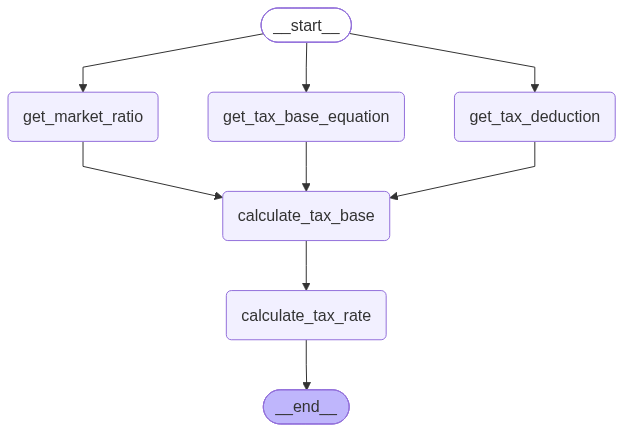

In [85]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 그래프 테스트

graph_test_state = {'query':query}
graph.invoke(graph_test_state)

context === {'query': '오늘날짜:(2026-10-11)에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?', 'follow_up_questions': None, 'answer': 'According to the sources, the official public fair market value rate for housing in 2026 is 60%. However, there are plans to increase this rate to 70% starting in 2027 for most homeowners, and to 80% for those owning three or more homes or homes in designated adjustment areas starting in 2028. The sources also mention that the exact rate and its application can vary based on the size of the property and the number of homes owned.', 'images': ['https://mblogthumb-phinf.pstatic.net/MjAyNjA4MDRfOTgg/MDAxNzg1ODE2NzM4ODI2.fj5xnoSqReUOMJuoL5T0IQTjiVFxu70nBu-C8-wZOQog.APU8G52MVDzGBpEG4A5sxB5v0tyn5qx_RM7jwqllq5Ug.PNG/2026_%EC%84%B8%EC%A0%9C%EA%B0%9C%ED%8E%B8%EC%95%88,_%EC%A2%85%EB%B6%80%EC%84%B8_%EA%B3%B5%EC%A0%95%EC%8B%9C%EC%9E%A5%EA%B0%80%EC%95%A1%EB%B9%84%EC%9C%A8_60%E2%86%9270_%EC%9D%B8%EC%83%81,_3%EC%A3%BC%ED%83%9D%EC%9E%90%EB%8A%94_80_%EC%A0%81%EC%9A%A9.png?type=w800', 'https

In [ ]:
"""
그래프를 invoke 하게 되면 시간이 오래걸린다.

small LLM -> 간단한 task는 경량화된 LLM으로 교체하게 되면,
* 비용 감소, 속도 향상에 도움이 됨.
"""